<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-最近傍法

In [5]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 25.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=433b5fa18a948fb2c1b04dcc1585cd6613163ddb1da90af691b6f1957eb7bfbb
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## 基本的な訓練と評価

In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# ─────────────────────────
# データの準備
# ─────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# k-NN では特徴量のスケーリングが必須
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ─────────────────────────
# モデルの構築と学習
# ─────────────────────────
knn = KNeighborsClassifier(
    n_neighbors=5,          # 近傍数 k
    weights='uniform',      # 重み方式（'uniform' or 'distance'）
    metric='minkowski',     # 距離尺度
    p=2,                    # ミンコフスキー距離のパラメータ（2=ユークリッド）
    algorithm='auto'        # 近傍探索アルゴリズム
)
knn.fit(X_train_sc, y_train)

# ─────────────────────────
# 予測と評価
# ─────────────────────────
y_pred = knn.predict(X_test_sc)

print(f"正解率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(
    y_test, y_pred, target_names=iris.target_names
))


正解率 (Accuracy): 0.9111

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



## 近傍の確認 ─ 予測の根拠を見る

In [7]:
# テストデータの先頭 1 件に対する近傍を調べる
distances, indices = knn.kneighbors(X_test_sc[:1], n_neighbors=5)

print("=== 予測対象 ===")
print(f"  真のクラス: {iris.target_names[y_test[0]]}")
print(f"  予測クラス: {iris.target_names[y_pred[0]]}")
print()
print("=== 5 近傍の詳細 ===")
print(f"{'#':>3s}  {'距離':>8s}  {'クラス':<12s}")
print("-" * 30)
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
    label = iris.target_names[y_train[idx]]
    print(f"{rank:3d}  {dist:8.4f}  {label}")


=== 予測対象 ===
  真のクラス: virginica
  予測クラス: virginica

=== 5 近傍の詳細 ===
  #        距離  クラス         
------------------------------
  1    0.3021  virginica
  2    0.4560  virginica
  3    0.5510  virginica
  4    0.5909  virginica
  5    0.6187  virginica


## 最適な $k$ の探索（交差検証）

最適な k = 14（交差検証スコア: 0.9714）


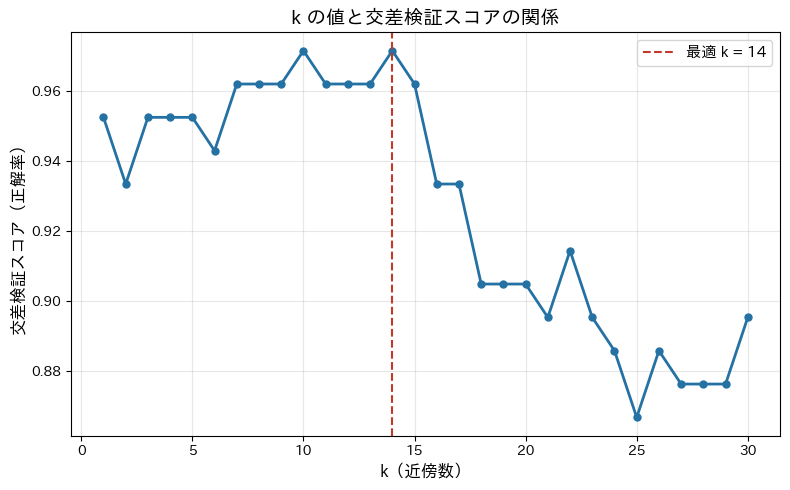

In [8]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import japanize_matplotlib

k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    scores = cross_val_score(knn_cv, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# 最適な k の特定
best_k = k_range[np.argmax(cv_scores)]
best_score = max(cv_scores)
print(f"最適な k = {best_k}（交差検証スコア: {best_score:.4f}）")

# プロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, cv_scores, 'o-', color='#2471A3', linewidth=2, markersize=5)
ax.axvline(x=best_k, color='#C0392B', linestyle='--', label=f'最適 k = {best_k}')
ax.set_xlabel('k（近傍数）', fontsize=12)
ax.set_ylabel('交差検証スコア（正解率）', fontsize=12)
ax.set_title('k の値と交差検証スコアの関係', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150)
plt.show()


## 決定境界の可視化（$k$ による変化の比較）

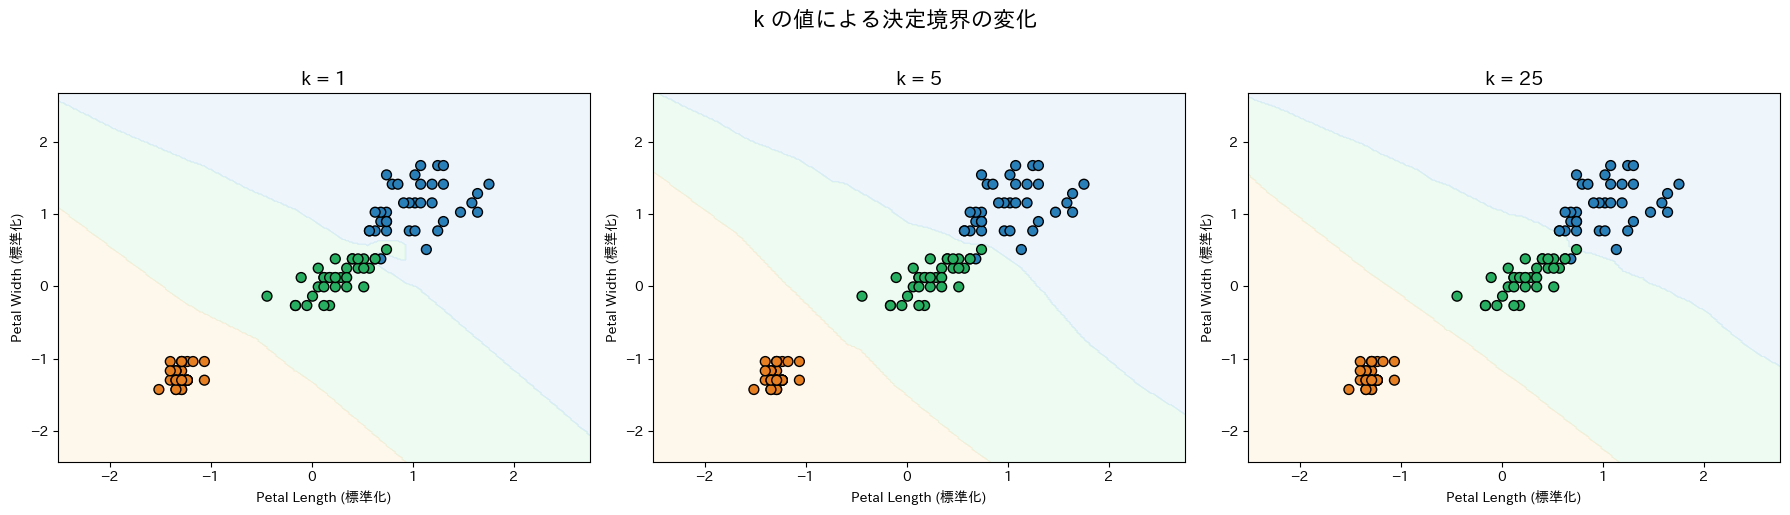

In [9]:
from matplotlib.colors import ListedColormap

# 2 特徴量に限定（petal length, petal width）
X_vis = iris.data[:, 2:4]
y_vis = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

# メッシュグリッドの生成
x_min, x_max = X_tr_sc[:, 0].min() - 1, X_tr_sc[:, 0].max() + 1
y_min, y_max = X_tr_sc[:, 1].min() - 1, X_tr_sc[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

# k = 1, 5, 25 での決定境界を比較
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [1, 5, 25]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_tr_sc, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr_sc[:, 0], X_tr_sc[:, 1], c=y_tr, cmap=cmap_pt,
               edgecolors='k', s=50)
    ax.set_title(f'k = {k}', fontsize=14)
    ax.set_xlabel('Petal Length (標準化)')
    ax.set_ylabel('Petal Width (標準化)')

plt.suptitle('k の値による決定境界の変化', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('knn_decision_boundaries.png', dpi=150)
plt.show()


## 重み方式の比較（uniform vs distance）

In [10]:
print(f"{'k':>4s}  |  {'uniform':>10s}  {'distance':>10s}")
print("-" * 36)

for k in [1, 3, 5, 7, 11, 15, 21]:
    scores_u = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, weights='uniform'),
        X_train_sc, y_train, cv=5
    )
    scores_d = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, weights='distance'),
        X_train_sc, y_train, cv=5
    )
    print(f"{k:4d}  |  {scores_u.mean():10.4f}  {scores_d.mean():10.4f}")

# 距離重みは，k が大きい場合に特に有効
# 遠い近傍の影響を自動的に弱めるため，k の選択に対してロバストになる


   k  |     uniform    distance
------------------------------------
   1  |      0.9524      0.9524
   3  |      0.9524      0.9524
   5  |      0.9524      0.9619
   7  |      0.9619      0.9619
  11  |      0.9619      0.9714
  15  |      0.9619      0.9714
  21  |      0.8952      0.9619


## 距離尺度の比較

In [14]:
metrics = {
    'ユークリッド (p=2)': {'metric': 'minkowski', 'p': 2},
    'マンハッタン (p=1)': {'metric': 'minkowski', 'p': 1},
    'チェビシェフ':       {'metric': 'chebyshev'},
}

print(f"{'距離尺度':<20s}  |  交差検証スコア (平均 ± 標準偏差)")
print("-" * 56)

for name, params in metrics.items():
    knn_m = KNeighborsClassifier(n_neighbors=5, weights='uniform', **params)
    scores = cross_val_score(knn_m, X_train_sc, y_train, cv=5)
    print(f"{name:<20s}  |  {scores.mean():.4f} ± {scores.std():.4f}")


距離尺度                  |  交差検証スコア (平均 ± 標準偏差)
--------------------------------------------------------
ユークリッド (p=2)          |  0.9524 ± 0.0426
マンハッタン (p=1)          |  0.9714 ± 0.0233
チェビシェフ                |  0.9333 ± 0.0233


## PCA と組み合わせた高次元データへの対応

In [15]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_digits

# 手書き数字データ（64 次元）
digits = load_digits()
X_d, y_d = digits.data, digits.target

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.3, random_state=42, stratify=y_d
)

# PCA で次元削減してから k-NN を適用するパイプライン
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),       # 64 次元 → 20 次元
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
pipeline.fit(X_d_train, y_d_train)
y_d_pred = pipeline.predict(X_d_test)

print(f"手書き数字分類（PCA + k-NN）")
print(f"正解率: {accuracy_score(y_d_test, y_d_pred):.4f}")
print()

# PCA なしとの比較
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
pipeline_no_pca.fit(X_d_train, y_d_train)
y_d_pred2 = pipeline_no_pca.predict(X_d_test)

print(f"手書き数字分類（k-NN のみ）")
print(f"正解率: {accuracy_score(y_d_test, y_d_pred2):.4f}")


手書き数字分類（PCA + k-NN）
正解率: 0.9667

手書き数字分類（k-NN のみ）
正解率: 0.9722
